In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

# 1. tensorflow v2.xx에서 v1사용하기

In [2]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior() # v2를 비활성화하고 v1활성화
import numpy as np
import pandas as pd

Instructions for updating:
non-resource variables are not supported in the long term


## Tensorflow
- 데이터 흐름 그래프(tensor객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session()으로 실행
- sess.run()을 통해 값을 확인

In [3]:
# tensor = data(상수, 변수)와 연산
node1 = tf.constant('Hello, Tensorflow')
sess = tf.Session()
print(sess.run(node1))

b'Hello, Tensorflow'


In [4]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype=tf.float16)
node2 = tf.constant(20, dtype=tf.float16)
node3 = tf.add(node1, node2)
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [5]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [6]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1., 2., 3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)

2.0

In [7]:
# 랜덤값을 갖는 tensor
a = tf.random_normal([2]) # 평균0, 표준편차가 1인 난수 실수 2개(정규분포이루는난수)
b = tf.random_normal([1])
sess = tf.Session()
sess.run([a,b])

[array([ 0.4578986, -0.9366754], dtype=float32),
 array([-0.18858676], dtype=float32)]

In [8]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w변수의 난수 초기화
sess.run(w)

array([0.1552496], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
## 2.1 입력(독립)변수 x가 1개, 타겟(종속)변수 y가 1개

In [9]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight 오 bias(처음엔 랜덤값으로 셋팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')
# Hypathesis : 예측값
H = W*x + b
# cost funstion(손실함수 = mse;최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습목적 : cost가 최소가 되는 W, b를 찾아내는 것
cost는 2차함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강)
=> GradientDescentOptimizer
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
# Session 생성
sess = tf.Session()
# W, b 변수 노드에 초기화
sess.run(tf.global_variables_initializer())
# 5000번 학습 (v2에서는 fit함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b])
    if step%200 == 0:
        print("{}번째 cost:{}, W:{}, b:{}".format(step,
                                               cost_val,
                                               W_val,
                                               b_val))

0번째 cost:3.36487078666687, W:[2.1036835], b:[0.16514651]
200번째 cost:0.06736522167921066, W:[1.3007243], b:[0.31638303]
400번째 cost:0.02572333812713623, W:[1.1858295], b:[0.5775661]
600번째 cost:0.009822431020438671, W:[1.1148313], b:[0.7389615]
800번째 cost:0.0037506932858377695, W:[1.0709589], b:[0.83869386]
1000번째 cost:0.001432205201126635, W:[1.0438484], b:[0.9003225]
1200번째 cost:0.000546890078112483, W:[1.0270958], b:[0.9384051]
1400번째 cost:0.00020883133402094245, W:[1.0167435], b:[0.96193796]
1600번째 cost:7.974227628437802e-05, W:[1.0103465], b:[0.9764799]
1800번째 cost:3.0449358746409416e-05, W:[1.0063936], b:[0.98546606]
2000번째 cost:1.1627232197497506e-05, W:[1.003951], b:[0.9910188]
2200번째 cost:4.440314569365e-06, W:[1.0024415], b:[0.99444985]
2400번째 cost:1.695975356597046e-06, W:[1.001509], b:[0.99656993]
2600번째 cost:6.481961918325396e-07, W:[1.0009329], b:[0.9978796]
2800번째 cost:2.478384715232096e-07, W:[1.0005769], b:[0.9986887]
3000번째 cost:9.492027430724193e-08, W:[1.0003573], b:[0

In [10]:
# 최종적으로 나온 회귀식 : H = W*x +b
sess.run([W, b])

[array([1.0000087], dtype=float32), array([0.9999811], dtype=float32)]

In [11]:
W_, b_ = sess.run([W,b])
W_[0], b_[0]

(1.0000087, 0.9999811)

In [12]:
def predict(x):
    return W_[0]*x + b_[0]

In [13]:
input_x = int(input('입력값은 ?'))
print('예측값은 ', predict(input_x))

입력값은 ?3
예측값은  4.000007212162018


## 2.2 predict를 위한 placeholder이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드

In [14]:
# x = np.array([1,2,3])
x = tf.placeholder(tf.float16)
H = 1*x + 1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [15]:
# H = 2x+1
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,5,7,11,17])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W,b 초기화
# 5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b],
                                        feed_dict={x:x_data,
                                                  y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:54.395774841308594, W:[1.1830949], b:[0.3843537]
200째 : cost:0.00595239270478487, W:[2.0262372], b:[0.85976136]
400째 : cost:0.0005854854243807495, W:[2.0082285], b:[0.95601785]
600째 : cost:5.758378028986044e-05, W:[2.0025806], b:[0.98620653]
800째 : cost:5.665938260790426e-06, W:[2.0008094], b:[0.9956737]
1000째 : cost:5.573895123234252e-07, W:[2.000254], b:[0.9986433]
1200째 : cost:5.477340891957283e-08, W:[2.0000796], b:[0.9995742]
1400째 : cost:5.390847768182994e-09, W:[2.0000248], b:[0.9998666]
1600째 : cost:5.572132755204962e-10, W:[2.000008], b:[0.9999575]
1800째 : cost:6.789378087512787e-11, W:[2.0000029], b:[0.99998504]
2000째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2200째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2400째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2600째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
2800째 : cost:2.060005464821213e-11, W:[2.0000017], b:[0.99999213]
3000째 : cost:2.060005464821213

In [16]:
# 예측하기
sess.run(H, feed_dict={x:5})

array([11.000001], dtype=float32)

In [17]:
sess.run(H, feed_dict={x:np.array([5,6,7])})

array([11.000001, 13.000002, 15.000004], dtype=float32)

## 2.3 scale이 다른 데이터의 linear regression 구현(scale조정x)

In [18]:
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W,b 초기화
# 3000번 학습
for step in range(3001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b],
                                        feed_dict={x:x_data,
                                                  y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:3723.082763671875, W:[7.9245567], b:[1.1821907]
200째 : cost:83.70708465576172, W:[10.187117], b:[-0.51817995]
400째 : cost:83.5029525756836, W:[10.267706], b:[-1.1148826]
600째 : cost:83.48420715332031, W:[10.292115], b:[-1.2956196]
800째 : cost:83.48248291015625, W:[10.299508], b:[-1.3503636]
1000째 : cost:83.48231506347656, W:[10.301748], b:[-1.366945]
1200째 : cost:83.48231506347656, W:[10.302426], b:[-1.3719671]
1400째 : cost:83.4823226928711, W:[10.302631], b:[-1.3734888]
1600째 : cost:83.48231506347656, W:[10.302694], b:[-1.3739487]
1800째 : cost:83.48233032226562, W:[10.302712], b:[-1.3740873]
2000째 : cost:83.48229217529297, W:[10.302718], b:[-1.3741277]
2200째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
2400째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
2600째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
2800째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]
3000째 : cost:83.48233032226562, W:[10.302718], b:[-1.3741326]


In [19]:
# cost값이 멈춤 : local 최소값

## 2.4 scale이 다른 데이터의 linear regression을 구현(조정O)
### scale을 맞추기 : 모든 데이터를 일정 범위내로 조정
- normalization(정규화)
    - normalization = $\frac{X - Xmin}{Xmax - Xmin}$
        * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler이용)
- standardization(표준화) : 평균0, 표준편차1로 조정
    - standardization = $\frac{X - Xmean(평균)}{Xstd(표준편차)}$
        * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler이용)

In [20]:
# 라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min() ) / (x_data.max() - x_data.min())
scaled_y_data = (y_data - y_data.min() ) / (y_data.max() - y_data.min())
print(scaled_x_data)
print(scaled_y_data)

[0.         0.11111111 0.44444444 0.77777778 1.        ]
[0.         0.13043478 0.70652174 0.83695652 1.        ]


In [28]:
# 라이브러리를 쓰고 정규화 (MinMaxScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1, 1)
# np.column_stack([x_data, y_data])
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler() # x_data를 정규화시킬 객체
# scaler_x.fit(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaler_y = MinMaxScaler() # y_data를 정규화시킬 객체
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [29]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W,b 초기화
# 2000번 학습
for step in range(12001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b],
                                        feed_dict={x:scaled_x_data,
                                                  y:scaled_y_data})
    if step%600 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:0.10232619941234589, W:[0.97008467], b:[-0.22090945]
600째 : cost:0.015308765694499016, W:[1.0564522], b:[-0.02950108]
1200째 : cost:0.01075595524162054, W:[1.06833], b:[0.01723756]
1800째 : cost:0.010376924648880959, W:[1.0645167], b:[0.03110784]
2400째 : cost:0.010243582539260387, W:[1.05804], b:[0.03718127]
3000째 : cost:0.010150404646992683, W:[1.0516989], b:[0.04112299]
3600째 : cost:0.010080346837639809, W:[1.0460275], b:[0.04425111]
4200째 : cost:0.01002739742398262, W:[1.0410608], b:[0.04690422]
4800째 : cost:0.009987354278564453, W:[1.0367336], b:[0.04919621]
5400째 : cost:0.009957083500921726, W:[1.0329702], b:[0.05118585]
6000째 : cost:0.009934190660715103, W:[1.0296962], b:[0.05291514]
6600째 : cost:0.009916884824633598, W:[1.0268506], b:[0.05441868]
7200째 : cost:0.0099038016051054, W:[1.0243751], b:[0.05572604]
7800째 : cost:0.009893909096717834, W:[1.0222236], b:[0.0568628]
8400째 : cost:0.009886419400572777, W:[1.020351], b:[0.0578512]
9000째 : cost:0.009880765341222286, W:[

In [30]:
# 예측 : 모델에 scale 조정된 값으로 예측=>scale 조정된 y값
scaled_input = scaler_x.transform(np.array([[2],
                                            [3]]))
print('모델 예측을 위한 입력 :', scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :',scaled_output, sep='\n')
print('결과 :', scaler_y.inverse_transform(scaled_output), sep='\n')

모델 예측을 위한 입력 :
[[0.11111111]
 [0.22222222]]
모델 예측 결과 :
[[0.17417616]
 [0.28676158]]
결과 :
[[19.024206]
 [29.382065]]


In [31]:
scaled_x_data

array([[0.        ],
       [0.11111111],
       [0.44444444],
       [0.77777778],
       [1.        ]])

In [32]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

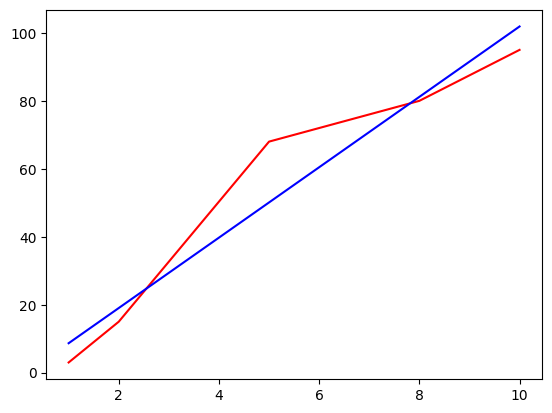

In [33]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

In [35]:
# 라이브러리를 쓰고 표준화 (StandardScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1,1)

from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # x_data를 표준화할 객체
scaler_y = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [36]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)
# Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W,b 초기화
# 2000번 학습
for step in range(12001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b],
                                        feed_dict={x:scaled_x_data,
                                                  y:scaled_y_data})
    if step%600 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:0.39754244685173035, W:[1.1839677], b:[-0.5356691]
600째 : cost:0.09299028664827347, W:[1.0330744], b:[-0.16114688]
1200째 : cost:0.06542827934026718, W:[0.98768145], b:[-0.04847822]
1800째 : cost:0.06293390691280365, W:[0.9740257], b:[-0.01458381]
2400째 : cost:0.06270815432071686, W:[0.96991765], b:[-0.00438727]
3000째 : cost:0.06268773227930069, W:[0.9686819], b:[-0.00131983]
3600째 : cost:0.06268588453531265, W:[0.96831], b:[-0.00039704]
4200째 : cost:0.06268571317195892, W:[0.968198], b:[-0.00011943]
4800째 : cost:0.06268570572137833, W:[0.9681648], b:[-3.5922425e-05]
5400째 : cost:0.06268569827079773, W:[0.9681648], b:[-1.0803622e-05]
6000째 : cost:0.06268571317195892, W:[0.9681648], b:[-3.2473276e-06]
6600째 : cost:0.06268571317195892, W:[0.9681648], b:[-9.744668e-07]
7200째 : cost:0.06268571317195892, W:[0.9681648], b:[-2.896245e-07]
7800째 : cost:0.06268570572137833, W:[0.9681648], b:[-8.3592475e-08]
8400째 : cost:0.06268571317195892, W:[0.9681648], b:[-2.9456617e-08]
9000째 : cost

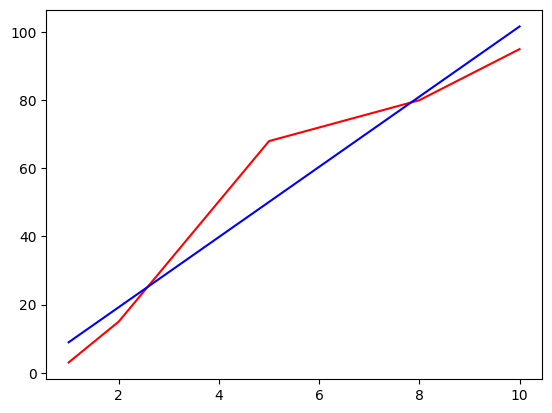

In [37]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')